El Framingham Heart Study es un estudio realizado en 1948 que estudia las enfermedades cardíacas así como factores que provocan enfermedades cardiovasculares.

En el dataset se posee información de pacientes, así como datos demográficos, sexo, peso y otros factores que afectan al corazón.

Si bien algunos factores como hábitos, sean ya fumar o consumir demasiado azúcar (glucosa) desarrollan enfermedades coronarias, otros factores como el peso o factores genéticos afectan al desarrollo de ésta. 



Hipótesis iniciales 

Edad: Se espera que sea la variable más influyente, pues el riesgo suele aumentar con la edad.

Educación: Se espera una relación indirecta o débil, pues es un indicador socioeconómico.

Colesterol total: Se espera una asociación positiva.

Fumar tiene una relación muy fuerte con riesgos.





In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


Lectura de datos

In [3]:
from pathlib import Path

ruta = Path("data/framingham.csv")

if not ruta.exists():
    ruta = Path("../data/framingham.csv")

df = pd.read_csv(ruta)
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [6]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [7]:
df.describe

<bound method NDFrame.describe of       male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0      

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [9]:
df.shape

(4240, 16)

Hipótesis previas

1. La edad es un factor de alta importancia, pues a mayor edad, más mortalidad y probabilidad de desarrollar una enfermedad coronaria.
2. La presión arterial junto al colesterol provocan mayor riesgo de desarrollar una enfermedad coronaria.
3. Las variables como la educación o la diabetes no están tan relacionadas con el desarrollo de una enfermedad.

Limpieza

In [10]:
import numpy as np      #IA USADA#


df = df.replace("NA", np.nan)


bin_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
for col in bin_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


df['education'] = df['education'].fillna(df['education'].mode()[0])


num_cols = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


df.loc[df['currentSmoker'] == 0, 'cigsPerDay'] = df.loc[df['currentSmoker'] == 0, 'cigsPerDay'].fillna(0)

Lectura y análisis del dataset

In [11]:
df.isnull().sum().sort_values(ascending=False)

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

El dataset tiene 4240 filas y 16 columnas, siendo una de ellas la target (enfermedad coronaria).
El valor nulo más destacado es el de la glucosa así como educación.
No parece que haya duplicados.
Hay 7 variables binarias: sexo, fumador, ictus, medicación, hipertensión, diabetes y riesgo de enfermedad coronaria a 10 años.

Análisis univariable

Estadísticas descriptivas

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.0000,0.0,1.0000,1.0
age,4240.0,49.580189,8.572942,32.00,42.0000,49.0,56.0000,70.0
education,4240.0,1.955189,1.018522,1.00,1.0000,2.0,3.0000,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.0000,0.0,1.0000,1.0
cigsPerDay,4240.0,8.944340,11.904777,0.00,0.0000,0.0,20.0000,70.0
BPMeds,4240.0,0.029245,0.168513,0.00,0.0000,0.0,0.0000,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.0000,0.0,0.0000,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.0000,0.0,1.0000,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.0000,0.0,0.0000,1.0
totChol,4240.0,236.667689,44.328480,107.00,206.0000,234.0,262.0000,696.0


In [14]:
continuous_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
df[continuous_cols].describe().T   #IA USADA PARA RECOGER LAS COLUMNAS#

,count,mean,std,min,25%,50%,75%,max
age,4240.0,49.580189,8.572942,32.00,42.0000,49.0,56.0000,70.0
cigsPerDay,4240.0,8.944340,11.904777,0.00,0.0000,0.0,20.0000,70.0
totChol,4240.0,236.667689,44.328480,107.00,206.0000,234.0,262.0000,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.0000,128.0,144.0000,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.0000,82.0,90.0000,142.5
BMI,4240.0,25.799005,4.070775,15.54,23.0775,25.4,28.0325,56.8
heartRate,4240.0,75.878774,12.023937,44.00,68.0000,75.0,83.0000,143.0
glucose,4240.0,81.600943,22.860340,40.00,72.0000,78.0,85.0000,394.0


In [15]:
binary_cols = ["male", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes", "TenYearCHD"]

for col in binary_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()         #IA USADA PARA RECOGER COLUMNAS Y REPRESENTARLAS#

--- male ---
male
0    2420
1    1820
Name: count, dtype: int64

--- currentSmoker ---
currentSmoker
0    2145
1    2095
Name: count, dtype: int64

--- BPMeds ---
BPMeds
0.0    4116
1.0     124
Name: count, dtype: int64

--- prevalentStroke ---
prevalentStroke
0    4215
1      25
Name: count, dtype: int64

--- prevalentHyp ---
prevalentHyp
0    2923
1    1317
Name: count, dtype: int64

--- diabetes ---
diabetes
0    4131
1     109
Name: count, dtype: int64

--- TenYearCHD ---
TenYearCHD
0    3596
1     644
Name: count, dtype: int64



In [16]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

In [17]:
print("Porcentaje de pacientes con CHD:", round(df["TenYearCHD"].mean() * 100, 1), "%")

#IA USADA PARA REPRESENTAR EL CÓDIGO CON PALABRAS#

Porcentaje de pacientes con CHD: 15.2 %


In [18]:
df["education"].value_counts().sort_index()

education
1.0    1825
2.0    1253
3.0     689
4.0     473
Name: count, dtype: int64

Visualización

Análisis univariable


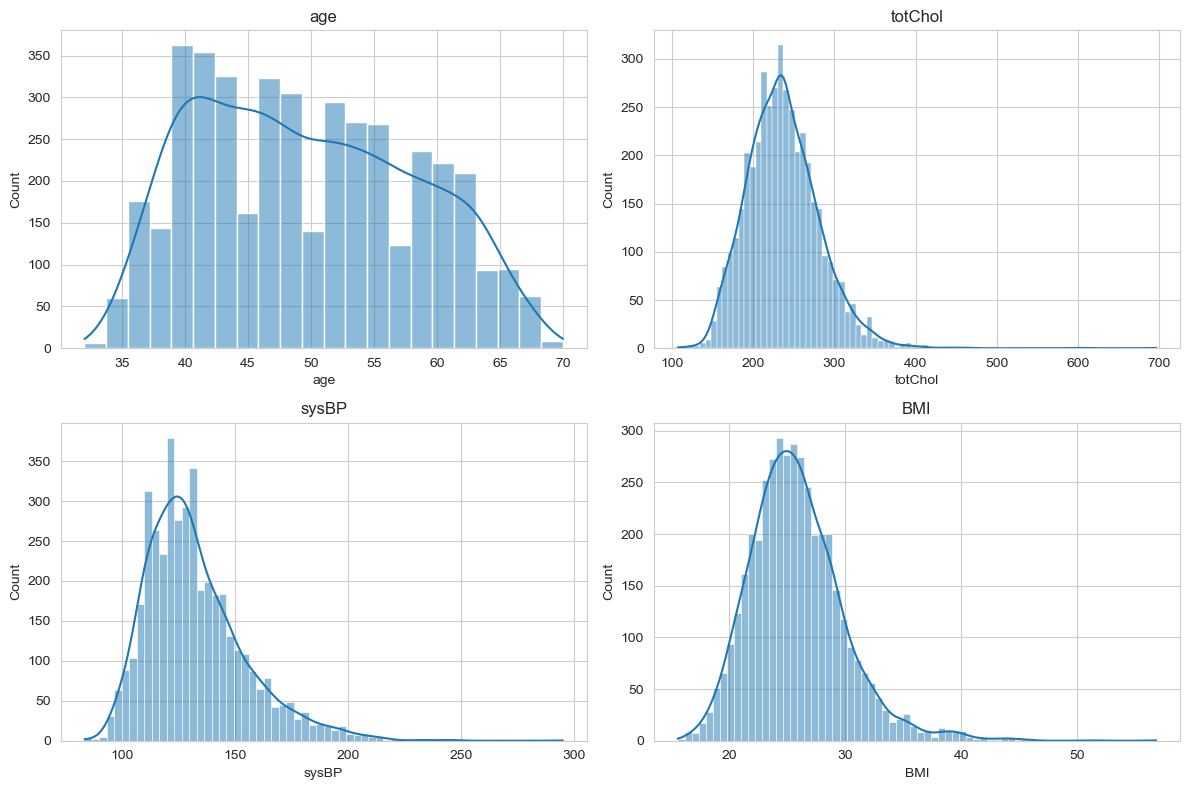

In [19]:
cols = ["age", "totChol", "sysBP", "BMI"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

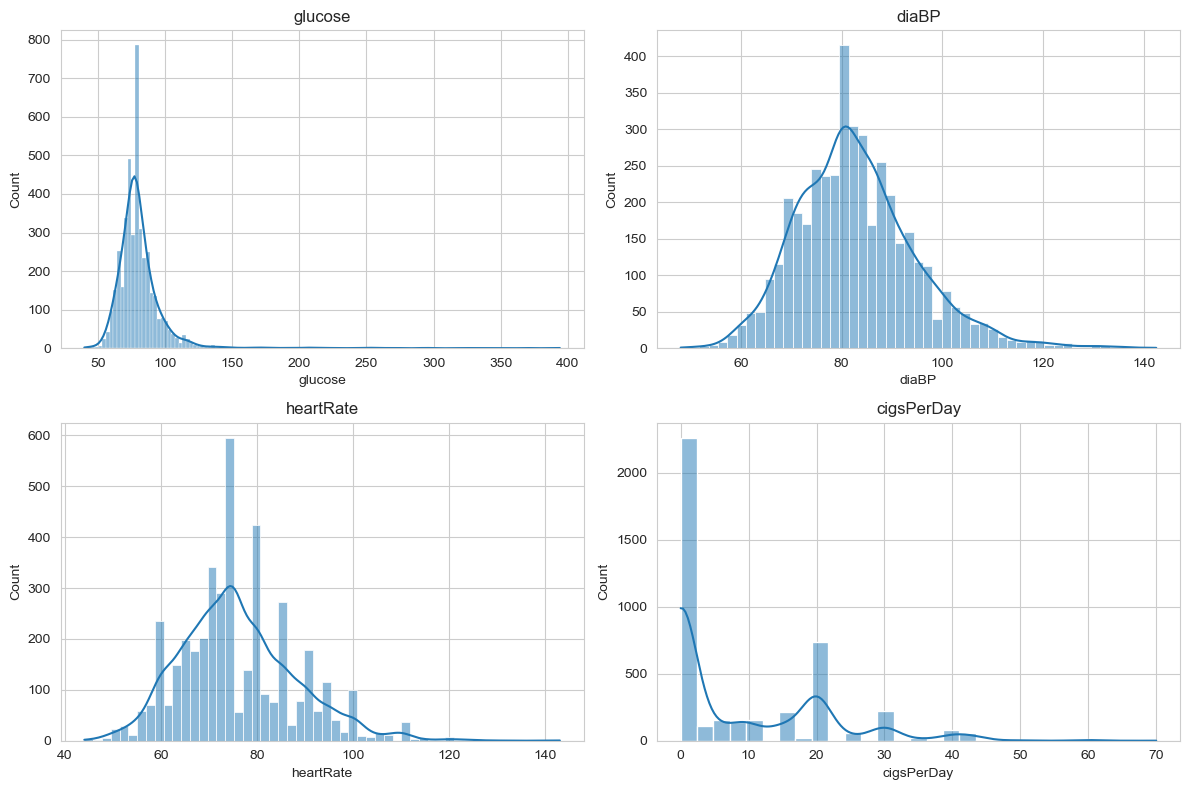

In [20]:
cols = ["glucose", "diaBP", "heartRate", "cigsPerDay"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Boxplots para ver posibles outliers

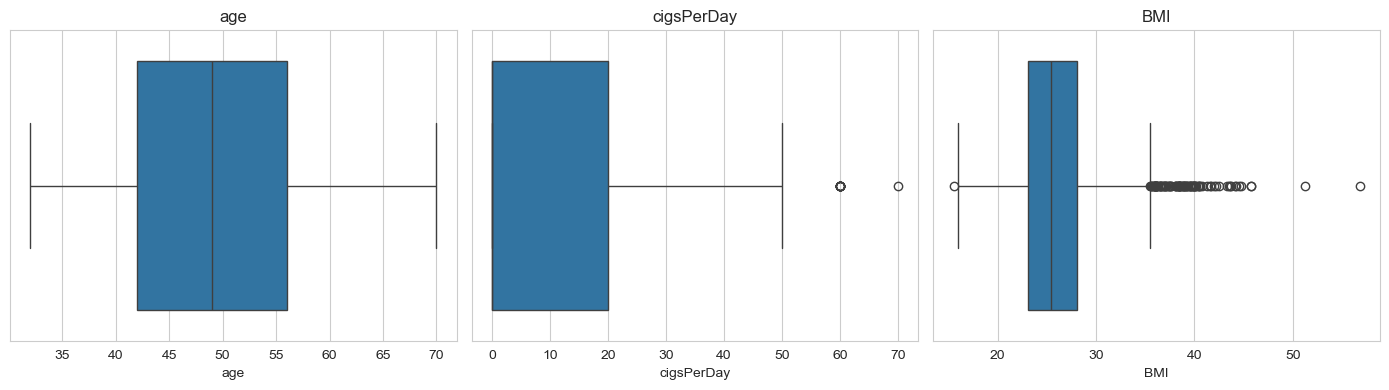

In [21]:
cols = ["age" , "cigsPerDay", "BMI"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Distribuciones

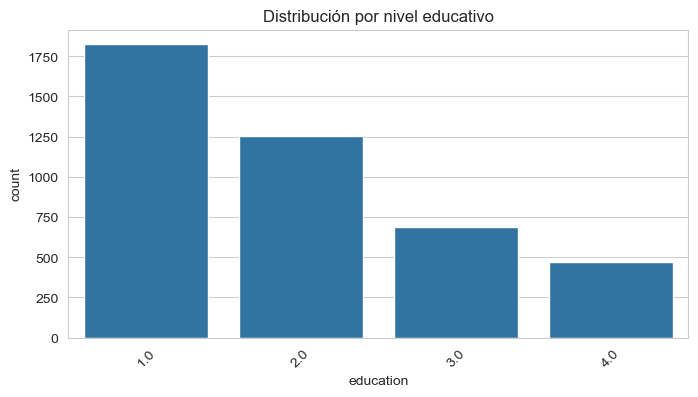

In [22]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="education", order=df["education"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribución por nivel educativo")
plt.show()

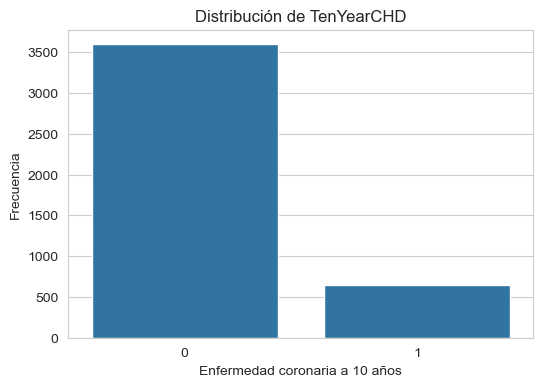

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="TenYearCHD")
plt.title("Distribución de TenYearCHD")
plt.xlabel("Enfermedad coronaria a 10 años")
plt.ylabel("Frecuencia")
plt.show()

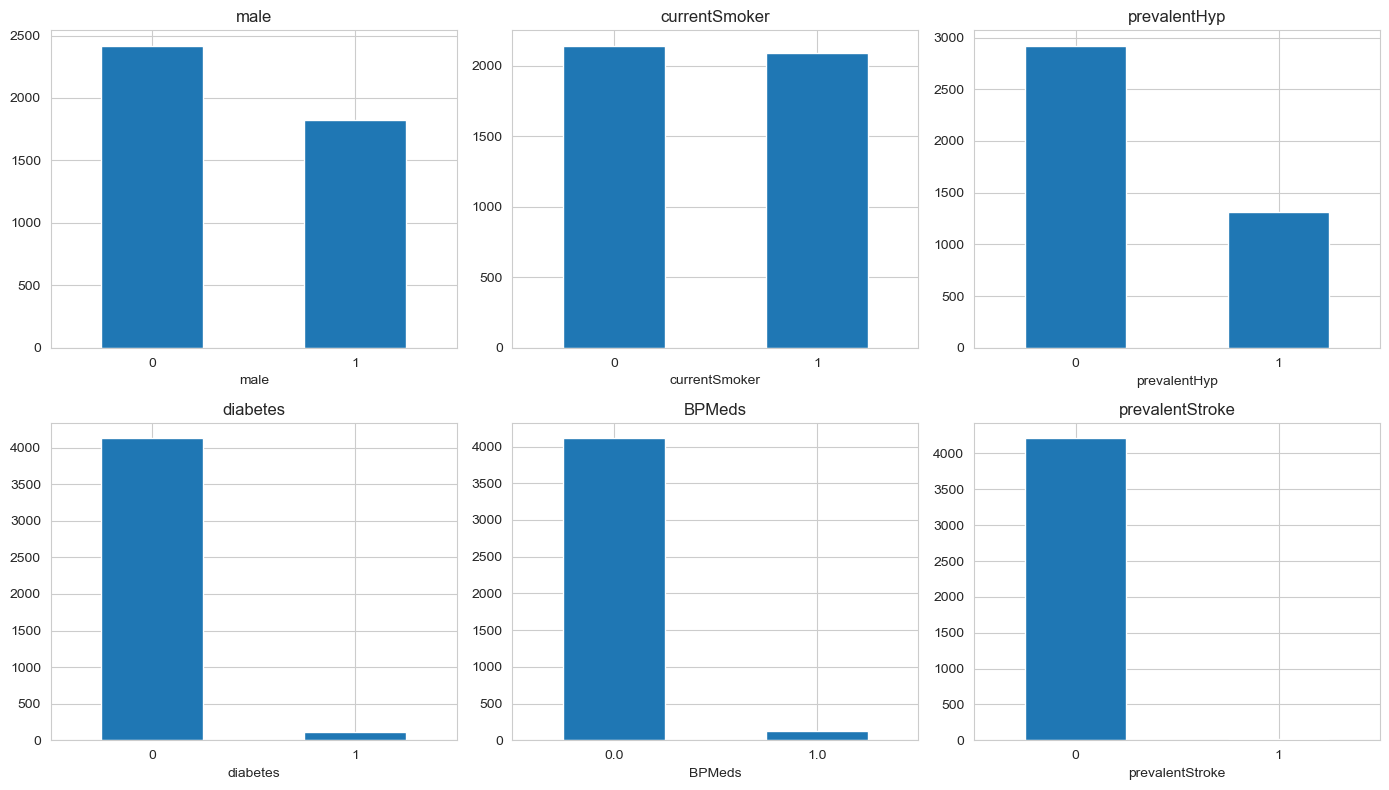

In [24]:
binary_cols = ["male", "currentSmoker", "prevalentHyp", "diabetes", "BPMeds", "prevalentStroke"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), binary_cols):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()   #IA USADA#

Comentarios: 

El target está desbalanceado; un 15% de los pacientes desarrollaron CHD.

La edad va de los 32 a los 70 años, con una distribución uniforme.

TotChol tiene algun valor extremo por encima de 600.

La glucosa tiene sesgo a la derecha; posible existencia de outliers.

CigsperDay tiene muchos ceros, pues incluye a los no fumadores.

Variables como ictus, diabetes y medicación tienen pocos casos positivos, es posible que limiten su utilidad en el análisis.

Análisis multivariable

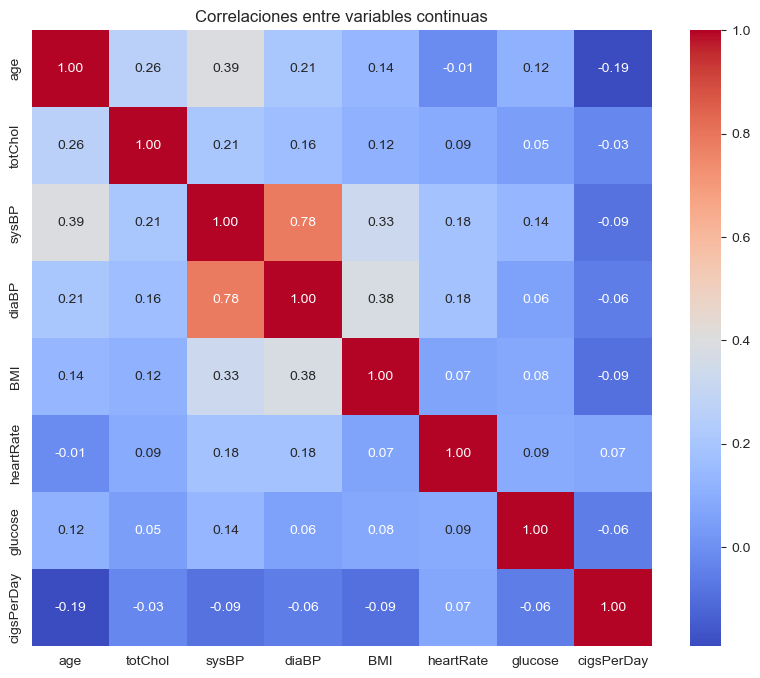

In [25]:
continuous_cols = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose", "cigsPerDay"]

corr = df[continuous_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlaciones entre variables continuas")
plt.show()

#IA USADA PARA RECOGER COLUMNAS#

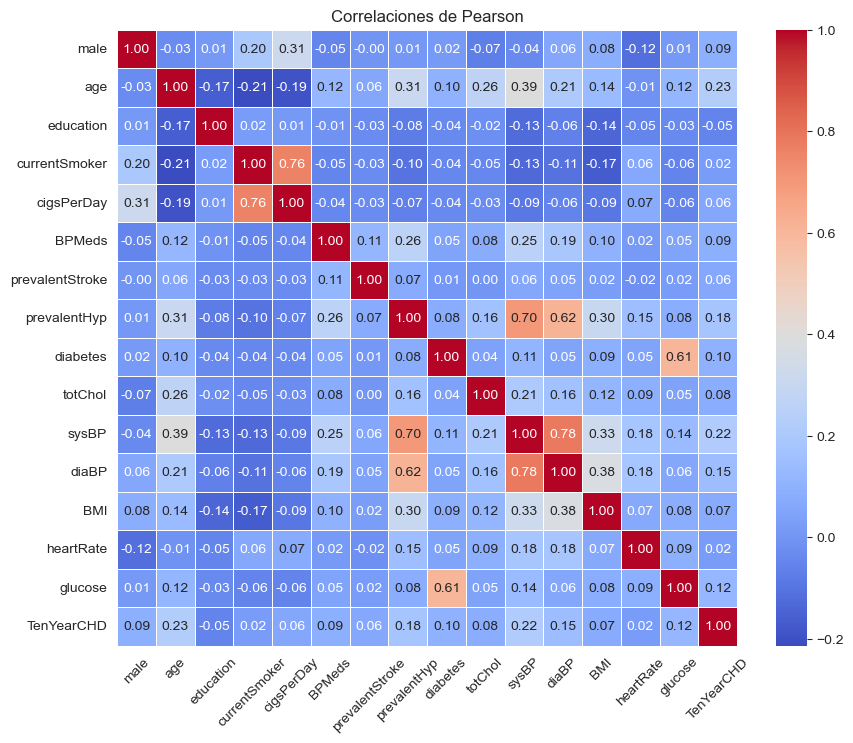

In [26]:
corr = df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlaciones de Pearson")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()   #IA USADA PARA CORREGIR SINTAXIS DEL CÓDIGO

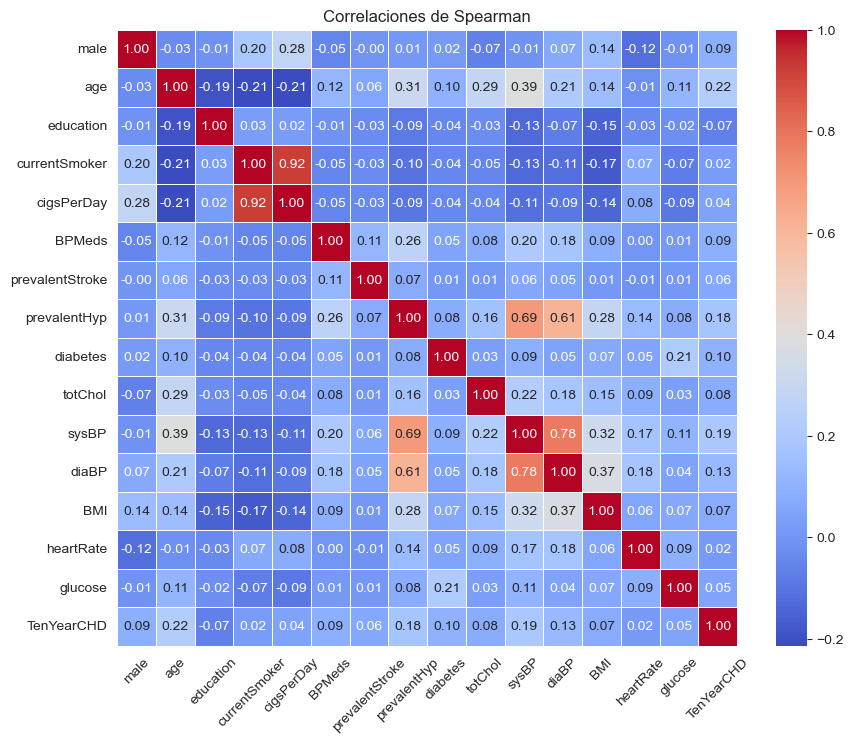

In [27]:
corr = df.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlaciones de Spearman")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

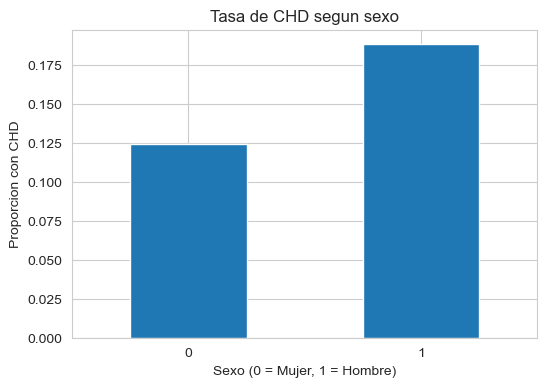

In [28]:
chd_by_sex = df.groupby("male")["TenYearCHD"].mean()

plt.figure(figsize=(6, 4))
chd_by_sex.plot(kind="bar")
plt.title("Tasa de CHD segun sexo")
plt.xlabel("Sexo (0 = Mujer, 1 = Hombre)")
plt.ylabel("Proporcion con CHD")
plt.xticks(rotation=0)
plt.show()

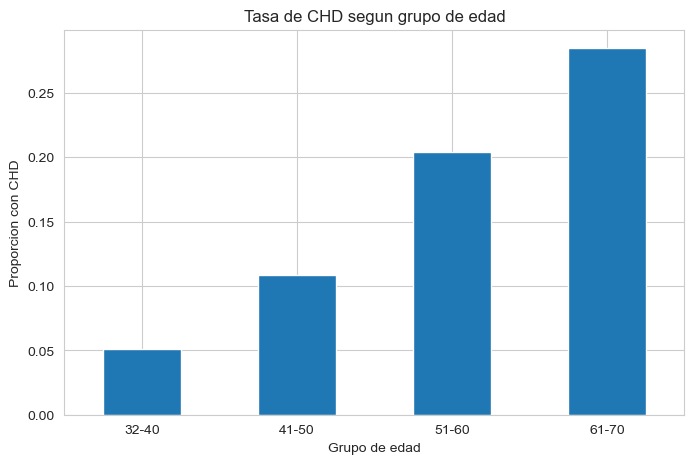

In [29]:
df["age_group"] = pd.cut(df["age"], bins=[30, 40, 50, 60, 70], labels=["32-40", "41-50", "51-60", "61-70"])

chd_by_age = df.groupby("age_group")["TenYearCHD"].mean()

plt.figure(figsize=(8, 5))
chd_by_age.plot(kind="bar")
plt.title("Tasa de CHD segun grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Proporcion con CHD")
plt.xticks(rotation=0)
plt.show()

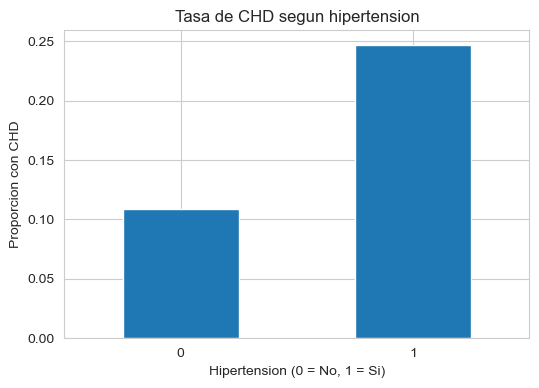

In [30]:
chd_by_hyp = df.groupby("prevalentHyp")["TenYearCHD"].mean()

plt.figure(figsize=(6, 4))
chd_by_hyp.plot(kind="bar")
plt.title("Tasa de CHD segun hipertension")
plt.xlabel("Hipertension (0 = No, 1 = Si)")
plt.ylabel("Proporcion con CHD")
plt.xticks(rotation=0)
plt.show()

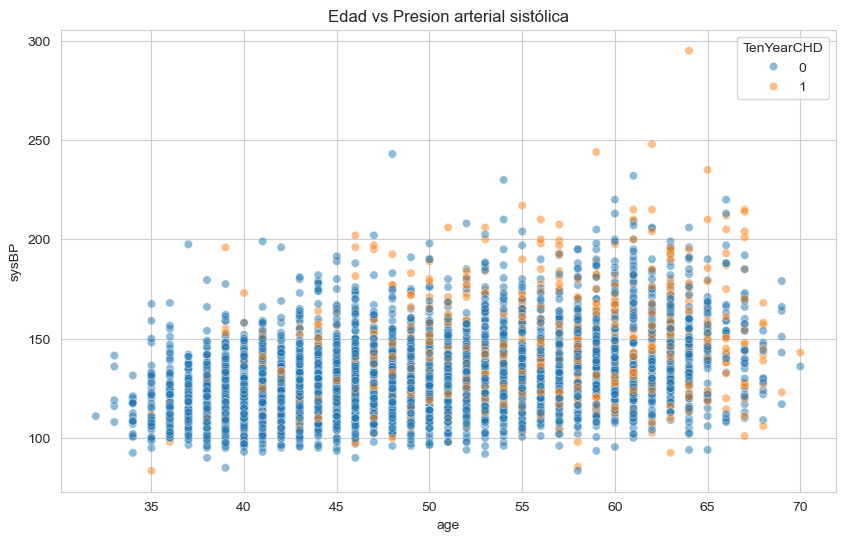

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="sysBP", hue="TenYearCHD", alpha=0.5)
plt.title("Edad vs Presion arterial sistólica")
plt.show()

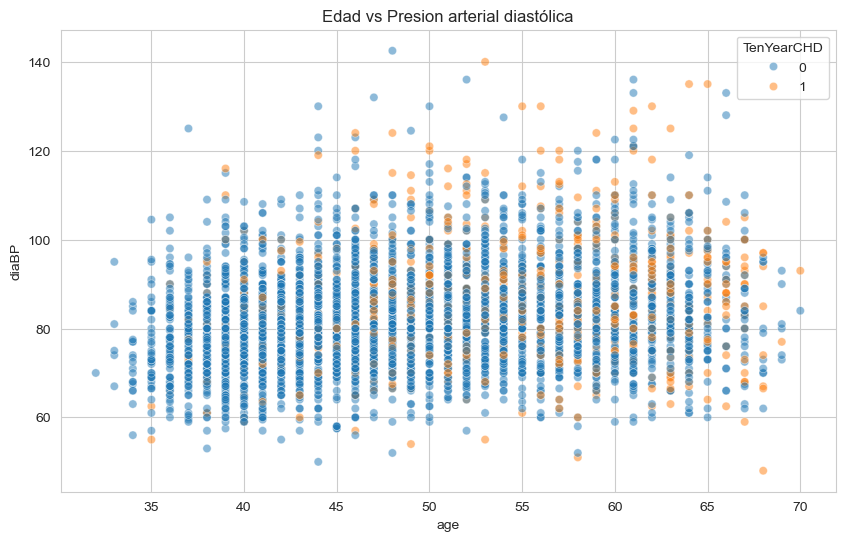

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="diaBP", hue="TenYearCHD", alpha=0.5)
plt.title("Edad vs Presion arterial diastólica")
plt.show()

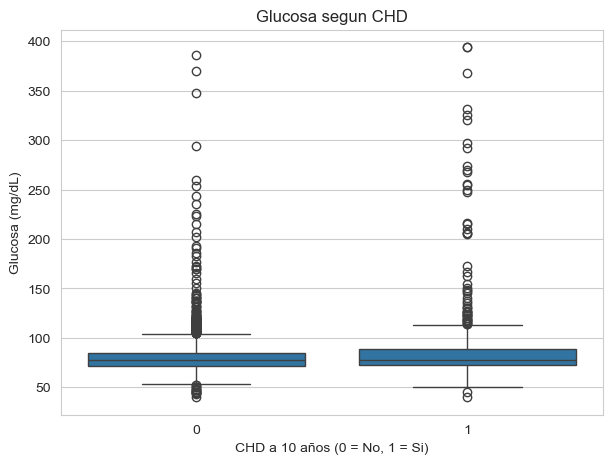

In [33]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="TenYearCHD", y="glucose")
plt.title("Glucosa segun CHD")
plt.xlabel("CHD a 10 años (0 = No, 1 = Si)")
plt.ylabel("Glucosa (mg/dL)")
plt.show()

#IA USADA PARA TRADUCIR PALABRAS A CÓDIGO#

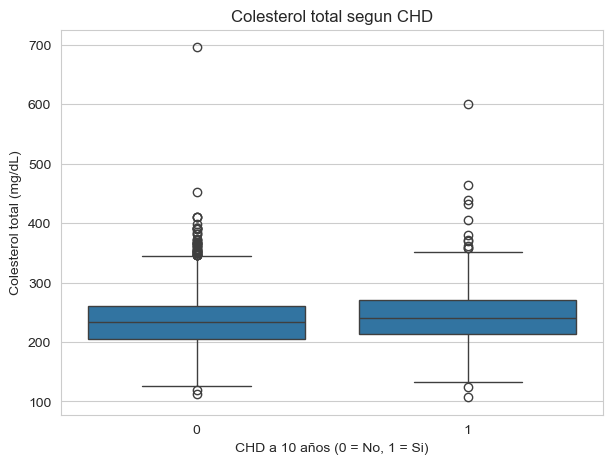

In [34]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="TenYearCHD", y="totChol")
plt.title("Colesterol total segun CHD")
plt.xlabel("CHD a 10 años (0 = No, 1 = Si)")
plt.ylabel("Colesterol total (mg/dL)")
plt.show()

Comentarios: 

Entre las variables continuas, age y sysBP son las que más correlación tienen entre sí y con los factores de riesgo en general. La glucosa también muestra  relación.

Las variables binarias se analizan a parte con tasas de CHD, así no se mete todo en el diagrama de Pearson. Los hombres tienen además una alta tasa de CHD en comparación a las mujeres.

La tasa de CHD sube de forma clara con la edad: pasando de 5% en el grupo más joven a casi un 28% en el rango de 61-70 años.

Los pacientes con hipertensión tienen más del doble de riesgo que los que no la tienen.

Fumar tiene una pequeña diferencia en la tasa de CHD, puede que dependa sobre todo de la marca y tamaño de cigarros.





Análisis bivariante 

,variable,n,tasa_CHD_%
0,male,2420,12.438017
1,male,1820,18.846154
2,currentSmoker,2145,14.498834
3,currentSmoker,2095,15.894988
4,prevalentHyp,2923,10.913445


,male,n,tasa_CHD,variable,currentSmoker,prevalentHyp,diabetes,BPMeds,prevalentStroke,tasa_CHD_%
0,0.0,2420,0.124380,male,NaN,NaN,NaN,NaN,NaN,12.438017
1,1.0,1820,0.188462,male,NaN,NaN,NaN,NaN,NaN,18.846154
2,NaN,2145,0.144988,currentSmoker,0.0,NaN,NaN,NaN,NaN,14.498834
3,NaN,2095,0.158950,currentSmoker,1.0,NaN,NaN,NaN,NaN,15.894988
4,NaN,2923,0.109134,prevalentHyp,NaN,0.0,NaN,NaN,NaN,10.913445
5,NaN,1317,0.246773,prevalentHyp,NaN,1.0,NaN,NaN,NaN,24.677297
6,NaN,4131,0.146212,diabetes,NaN,NaN,0.0,NaN,NaN,14.621157
7,NaN,109,0.366972,diabetes,NaN,NaN,1.0,NaN,NaN,36.697248
8,NaN,4116,0.146501,BPMeds,NaN,NaN,NaN,0.0,NaN,14.650146
9,NaN,124,0.330645,BPMeds,NaN,NaN,NaN,1.0,NaN,33.064516


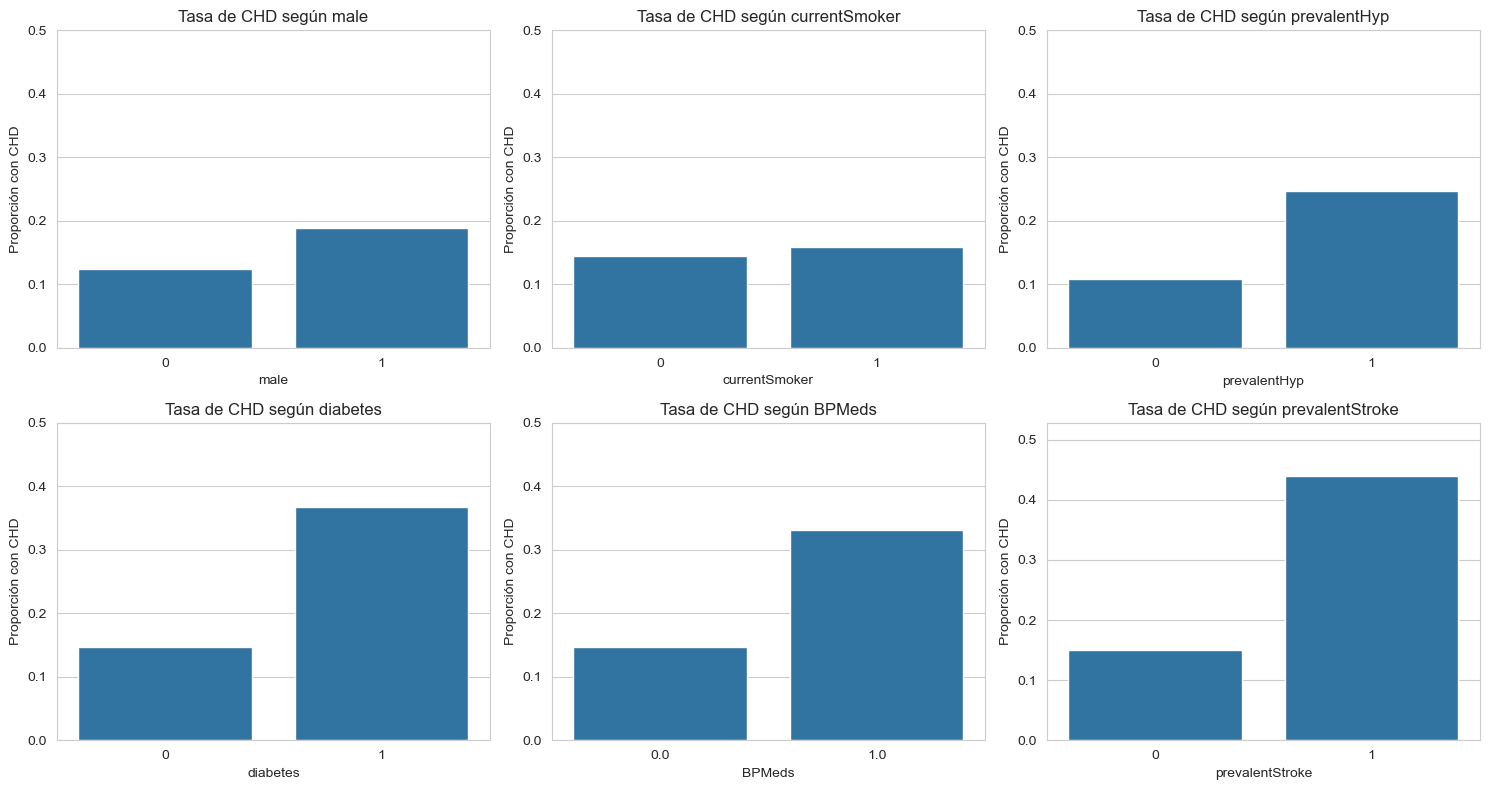

In [ ]:
risk_binary = []

for col in [c for c in binary_cols if c != "TenYearCHD"]:
    tmp = (
        df.groupby(col, dropna=False)["TenYearCHD"]
        .agg(n="count", tasa_CHD="mean")
        .reset_index()
    )
    tmp["variable"] = col
    risk_binary.append(tmp)

risk_binary = pd.concat(risk_binary, ignore_index=True)
risk_binary["tasa_CHD_%"] = 100 * risk_binary["tasa_CHD"]

display(risk_binary[["variable", "n", "tasa_CHD_%"]].head())
display(risk_binary)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, [c for c in binary_cols if c != "TenYearCHD"]):
    rates = df.groupby(col, dropna=False)["TenYearCHD"].mean().reset_index()
    sns.barplot(data=rates, x=col, y="TenYearCHD", ax=ax, color="C0")
    ax.set_title(f"Tasa de CHD según {col}")
    ax.set_ylabel("Proporción con CHD")
    ax.set_xlabel(col)
    ax.set_ylim(0, max(0.5, rates["TenYearCHD"].max() * 1.2))

plt.tight_layout()
plt.show()   #IA USADA#

In [36]:
num_by_target = (
    df.groupby("TenYearCHD")[continuous_cols]
    .agg(["mean", "median", "std", "count"])
    .T
)

display(num_by_target)

TenYearCHD                   0           1
age        mean      48.762514   54.145963
           median    48.000000   55.000000
           std        8.413963    8.005663
           count   3596.000000  644.000000
totChol    mean     235.134316  245.229814
           median   233.000000  240.500000
           std       43.515636   47.756803
           count   3596.000000  644.000000
sysBP      mean     130.337319  143.618789
           median   127.000000  139.000000
           std       20.450363   26.690282
           count   3596.000000  644.000000
diaBP      mean      82.166435   86.981366
           median    81.000000   85.500000
           std       11.338252   14.026900
           count   3596.000000  644.000000
BMI        mean      25.670979   26.513882
           median    25.260000   26.090000
           std        3.978384    4.489019
           count   3596.000000  644.000000
heartRate  mean      75.762514   76.527950
           median    75.000000   75.000000
           std       11.988209   12.210600
           count   3596.000000  644.000000
glucose    mean      80.427419   88.153727
           median    78.000000   78.000000
           std       18.066467   39.618668
           count   3596.000000  644.000000
cigsPerDay mean       8.648498   10.596273
           median     0.000000    2.000000
           std       11.675131   12.999882
           count   3596.000000  644.000000

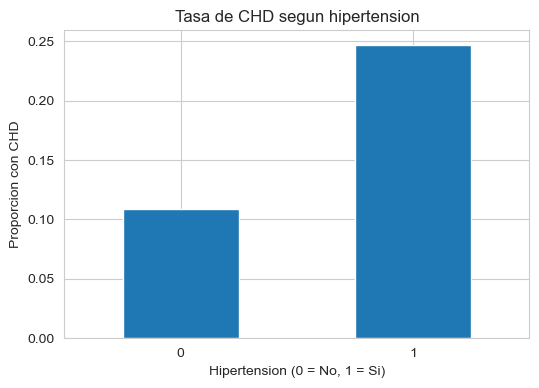

In [ ]:
chd_by_hyp = df.groupby("prevalentHyp")["TenYearCHD"].mean()

plt.figure(figsize=(6, 4))
chd_by_hyp.plot(kind="bar")
plt.title("Tasa de CHD segun hipertension")
plt.xlabel("Hipertension (0 = No, 1 = Si)")
plt.ylabel("Proporcion con CHD")
plt.xticks(rotation=0)
plt.show()  #IA USADA#

COMPARACIÓN FINAL CON LAS HIPÓTESIS

1. Se confirma que la edad es una de las variables más asociadas al riesgo.

2. La presión aterial y la hipertensión muestran una relación clara con mayor riesgo.

3. Los pacientes diabéticos tienen una tasa de CHD mayor y los valores altos de glucosa parecen concentrar más riesgo.

4. Los hombres sufren más de CHD que las mujeres.

5. Fumar tiene una correlación ligeramente fuerte con riesgos, no obstante, depende más aún de otras variables como la cantidad fumada.

6. No me ha dado tiempo a contrastar la educación con el riesgo, además, no me parece una variable significativa.